In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import os
import json
import scvi
import seaborn as sns
import matplotlib.cm as cm


from utils import preprocessing

TISSUE = "SN"

ADATA = f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/adatas/{TISSUE}/{TISSUE}_combined_QC_mmc.h5ad"

SAMPLE_VARIABLE = "donor_id"

SAVE_PATH = f"{os.path.splitext(ADATA)[0]}_ct-cured.h5ad"

For DFC and SN we just want:
- Astrocytes
- Endothelial
- Ependymal
- Neurons - SPN
- Neurons - non-SPN
- Microglia (includes macrophage and monocytes)
- Lymphocytes
- Oligodendrocytes
- OPC

# Process one tissue at a time

In [2]:
adata = sc.read_h5ad(ADATA)
print(adata)


AnnData object with n_obs × n_vars = 125635 × 38601
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'barcode', 'bcl', 'rna_index', 'library', 'library__barcode', 'frac_mito', 'mol_info_nUMI', 'mol_info_nRead', 'frac_intronic', 'donor_id', 'vireo_prob_max', 'vireo_prob_doublet', 'vireo_n_vars', 'vireo_best_singlet', 'vireo_best_doublet', 'vireo_doublet_logLikRatio', 'dropsift_frac_contamination', 'dropsift_training_label_is_cell', 'dropsift_empty_gene_module_score', 'dropsift_is_cell', 'dropsift_is_cell_prob', 'cell_class', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'tissue', 'broad_original_cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'brain_bank', 'cohort', 'condition', 'sex', 'age_of_on

In [3]:
def preprocess_common_pipeline(adata, umap_name="", leiden_name="", resolutions=[0.1, 0.5, 0.07], integrate_with_harmony=False, integrate_with_scvi=False, batch_key=None, categorical_covariate_keys=None):

    SEED =42
    
    adata.X = adata.layers["counts"].copy()
    sc.pp.normalize_total(adata, target_sum=1e4, inplace=True)
    sc.pp.log1p(adata)
    adata.layers["log1p_norm"] = adata.X.copy()

    # Cehck that all abtcjes have enight cells, otheriw use usail hvg method
    print("Running HVG...")
    try:
        sc.pp.highly_variable_genes(adata, n_top_genes=3000, flavor="seurat_v3", 
                                     layer="counts", batch_key=batch_key)
        print(f"HVG computed with batch_key='{batch_key}'")
    except ValueError as e:
        print(f"WARNING: HVG with batch_key failed ({e}), retrying without batch_key")
        sc.pp.highly_variable_genes(adata, n_top_genes=3000, flavor="seurat_v3", 
                                     layer="counts", batch_key=None)

    if integrate_with_scvi:
        import scvi
        # Train scVI
        adata_hvg = adata[:, adata.var.highly_variable].copy()  # temp copy, HVG only
        scvi.model.SCVI.setup_anndata(adata_hvg, layer="counts", batch_key=batch_key, categorical_covariate_keys=categorical_covariate_keys)
        model = scvi.model.SCVI(adata_hvg, n_layers=2, n_latent=30)
        model.train(batch_size=512, max_epochs=50)# datasplitter_kwargs={'num_workers': 16})

        loss_key = "elbo_train" if "elbo_train" in model.history else "train_loss_epoch"
        plt.plot(model.history[loss_key]); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.show()

        adata.obsm["X_scvi"] = model.get_latent_representation()
        sc.pp.neighbors(adata, use_rep="X_scvi", random_state=SEED)
        sc.tl.umap(adata, key_added=f"umap{umap_name}", random_state=SEED)

    elif integrate_with_harmony:
        print("Running Harmony...")
        import harmonypy
        if batch_key is None:
            raise ValueError("batch_key must be provided for Harmony integration.")
        sc.pp.scale(adata, max_value=10)
        sc.tl.pca(adata, svd_solver='arpack', n_comps=50, random_state=SEED)
        # Run Harmony on the PCA embedding
        ho = harmonypy.run_harmony(adata.obsm["X_pca"], adata.obs, vars_use=batch_key, max_iter_harmony=30)
        adata.obsm["X_pca_harmony"] = ho.Z_corr
        sc.pp.neighbors(adata, use_rep="X_pca_harmony", n_pcs=30, random_state=SEED)
        sc.tl.umap(adata, key_added=f"umap{umap_name}", random_state=SEED)
        
    else:
        sc.pp.scale(adata, max_value=10) #z-score normalization
        sc.tl.pca(adata, svd_solver='arpack', n_comps=50, random_state=SEED)
        sc.pp.neighbors(adata, use_rep='X_pca', n_pcs=30, random_state=SEED) # from X_pca
        sc.tl.umap(adata, key_added=f"umap{umap_name}", random_state=SEED) # uese neighbors

    for r in resolutions:
        sc.tl.leiden(adata, resolution=r, key_added=f"leiden_{r}{leiden_name}", flavor="igraph", n_iterations=2, random_state=SEED) # use neighbors
    leiden_cluster_names = [f"leiden_{r}{leiden_name}" for r in resolutions]
    return leiden_cluster_names

def which_clusters_are_split(adata, CLUSTERS_GROUP_ALL_CELLS_COL, MMC_ANNOTATION_LEVEL, CLEAN_THRESHOLD = 90):

    ct_per_cluster = (
        adata.obs
        .groupby([CLUSTERS_GROUP_ALL_CELLS_COL, MMC_ANNOTATION_LEVEL])
        .size() # eaw counts
        .unstack(fill_value=0) 
    )
    ct_per_cluster_pct = ct_per_cluster.div(ct_per_cluster.sum(axis=1), axis=0) * 100 # cal pct

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.heatmap(ct_per_cluster_pct, annot=True, fmt=".0f", cmap="Blues",
                cbar_kws={"label": "% of cluster"}, ax=ax)
    ax.set_title(f"{CLUSTERS_GROUP_ALL_CELLS_COL} x {MMC_ANNOTATION_LEVEL}  (% of cluster)")
    ax.set_xlabel("MMC label"); ax.set_ylabel("Cluster")
    plt.tight_layout(); plt.show()

    # for each clutser applu ruels to say if it ok or need ot investigate
    #CLEAN_THRESHOLD = 90   # % to call a cluster "clean"

    cluster_status = {}
    for cluster, row in ct_per_cluster_pct.iterrows():
        top_label  = row.idxmax()
        top_pct    = row.max()
        if top_pct >= CLEAN_THRESHOLD:
            status = "clean"
        else:
            status = "INVESTIGATE"   # mixed → check marker genes manually
        cluster_status[cluster] = {"top_label": top_label, "top_pct": top_pct, "status": status}

    cluster_status_df = pd.DataFrame(cluster_status).T
    display(cluster_status_df)


subclass_cell_types_mapping = {
    "MSN": [
        "STR D1 MSN", "STR D2 MSN", "STR Hybrid MSN",
    ],
    "non_MSN_neuron": [
        "ACx MEIS2 GABA", "CN Cholinergic GABA", "CN GABA-Glut",
        "CN LAMP5-CXCL14 GABA", "CN LAMP5-LHX6 GABA", "CN LHX8 GABA",
        "CN MEIS2 GABA", "CN ONECUT1 GABA", "CN ST18 GABA", "CN VIP GABA",
        "F GABA", "F Glut", "F M GATA3 GABA", "F M Glut", "M Dopa",
        "OT Granular GABA", "SN PAX7 GABA", "STR SST-CHODL GABA","STR RSPO2 GABA"
    ],
    "glia": [
        "Astrocyte", "COP", "Ependymal", "Oligodendrocyte", "OPC"
    ],
    "vascular": [
        "Endo", "Pericyte", "SMC", "VLMC"
    ],
    "immune": [
        "Lymphocyte", "Macrophage", "Microglia"
    ],
}

# reverse map: cell type → broad category (useful for adata.obs)
celltype_to_broad = {
    cell: broad
    for broad, cells in subclass_cell_types_mapping.items()
    for cell in cells
}

markers_ct = {
    "Ependymal":            ["FOXJ1", "TTR", "VWF", "ERG"],
    
    "Endothelial_BBB":      ["CLDN5", "OCLN", "SLC2A1", "MFSD2A"],  
    
    "Microglia":            ["P2RY12", "TMEM119", "FCRLS", "SALL1"],
    "Monocytes":            ["CCR2", "LY6C2", "S100A8", "S100A9", "CD300E"],
    "Macrophages":          ["MRC1", "LYVE1", "CD163", "LGALS3", "CD200R1"],

    "Lymphocytes":          ["CD3D", "CD3E", "CD8A", "GZMB", "CD19", "MS4A1", "CD79A", "CD79B"],
}


In [4]:
# Preprocess
leiden_cluster_names = preprocess_common_pipeline(adata, leiden_name="_all_cells", integrate_with_harmony=True, batch_key="library")

Running HVG...
HVG computed with batch_key='library'
Running Harmony...


/home/gdallagl/.pyenv/versions/3.11.8/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
2026-03-06 00:56:59,306 - harmonypy - INFO - Running Harmony (PyTorch on cuda)
2026-03-06 00:56:59,307 - harmonypy - INFO -   Parameters:
2026-03-06 00:56:59,308 - harmonypy - INFO -     max_iter_harmony: 30
2026-03-06 00:56:59,308 - harmonypy - INFO -     max_iter_kmeans: 20
2026-03-06 00:56:59,308 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-03-06 00:56:59,309 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-03-06 00:56:59,309 - harmonypy - INFO -     nclust: 100
2026-03-06 00:56:59,310 - harmonypy - INFO -     block_size: 0.05
2026-03-06 00:56:59,310 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1. 1. 1.]
2026-03-06 00:56:59,311 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2.]
2026-03-06 00:56:59,312 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-03-06 00:56:59,31

In [ ]:
cell_type_mapping = {

    # ── DA Neurons - SN (THE cells of interest in SN biology / Parkinson's) ─
    # These are the vulnerable midbrain dopaminergic neurons
    "SN SOX6 Dopa"                  : "DA Neurons - SN",   # largest DA population, most vulnerable in PD
    "SN-VTR CALB1 Dopa"             : "DA Neurons - SN",   # VTA/SN border, CALB1+ more resilient in PD
    "SN-VTR GAD2 Dopa"              : "DA Neurons - SN",   # co-release GABA+DA

    # ── GABA Neurons - SN (local interneurons of the SN) ─────────────────────
    "SN EBF2 GABA"                  : "GABA Neurons - SN",
    "SN GATA3-PVALB GABA"           : "GABA Neurons - SN",
    "SN SEMA5A GABA"                : "GABA Neurons - SN",
    "SN-VTR-HTH GATA3-TCF7L2 GABA" : "GABA Neurons - SN",

    # ── Basal Ganglia Neurons (neighboring regions, expected in SN dissection)─
    # GPe, GPi, STH are anatomically adjacent — their presence makes sense
    "GPe-NDB-SI LHX6-LHX8-GBX1 GABA"  : "Basal Ganglia Neurons",
    "GPe SOX6-CTXND1 GABA"             : "Basal Ganglia Neurons",
    "GPe MEIS2-SOX6 GABA"              : "Basal Ganglia Neurons",
    "GPi Core"                          : "Basal Ganglia Neurons",
    "GPi Shell"                         : "Basal Ganglia Neurons",
    "STH PVALB-PITX2 Glut"             : "Basal Ganglia Neurons",  # subthalamic nucleus
    "ZI-HTH GABA"                       : "Basal Ganglia Neurons",
    "VTR-HTH Glut"                      : "Basal Ganglia Neurons",
    "AMY-SLEA-BNST GABA"               : "Basal Ganglia Neurons",
    "AMY-SLEA-BNST D1 GABA"            : "Basal Ganglia Neurons",
    "BF SKOR1 Glut"                     : "Basal Ganglia Neurons",
    "VIP GABA"                          : "Basal Ganglia Neurons",
    "LAMP5-CXCL14 GABA"                : "Basal Ganglia Neurons",
    "LAMP5-LHX6 GABA"                  : "Basal Ganglia Neurons",
    "OB Dopa-GABA"                      : "Basal Ganglia Neurons",
    "OB FRMD7 GABA"                     : "Basal Ganglia Neurons",

    # ── Striatal Neurons (likely dissection edge contamination) ───────────────
    "STRv D1 NUDAP MSN"             : "Striatal Neurons",
    "STRv D2 MSN"                   : "Striatal Neurons",
    "STRv D1 MSN"                   : "Striatal Neurons",
    "STRd D1 Matrix MSN"            : "Striatal Neurons",
    "STRd D2 Matrix MSN"            : "Striatal Neurons",
    "STRd D1 Striosome MSN"         : "Striatal Neurons",
    "STRd D2 Striosome MSN"         : "Striatal Neurons",
    "STR SST-RSPO2 GABA"            : "Striatal Neurons",
    "STR SST-CHODL GABA"            : "Striatal Neurons",
    "STR LYPD6-RSPO2 GABA"          : "Striatal Neurons",
    "STR FS PTHLH-PVALB GABA"       : "Striatal Neurons",
    "STR-BF TAC3-PLPP4-LHX8 GABA"   : "Striatal Neurons",
    "STRd Cholinergic GABA"         : "Striatal Neurons",
    "STR Cholinergic GABA"          : "Striatal Neurons",
    "GPin-BF Cholinergic GABA"      : "Striatal Neurons",

    # ── Oligodendrocytes ──────────────────────────────────────────────────────
    "Oligo OPALIN"                  : "Oligodendrocytes",
    "Oligo PLEKHG1"                 : "Oligodendrocytes",
    "ImOligo"                       : "Oligodendrocytes",
    "COP"                           : "Oligodendrocytes",

    # ── OPC ───────────────────────────────────────────────────────────────────
    "OPC"                           : "OPC",

    # ── Astrocytes ────────────────────────────────────────────────────────────
    "Astrocyte"                     : "Astrocytes",
    "ImAstro"                       : "Astrocytes",

    # ── Microglia / Brain Immune ──────────────────────────────────────────────
    "Microglia"                     : "Microglia",
    "BAM"                           : "Microglia",      # border-associated macrophages
    "Monocyte"                      : "Microglia",

    # ── Peripheral Immune (likely blood contamination) ────────────────────────
    "T cells"                       : "Peripheral Immune",
    "B cells"                       : "Peripheral Immune",

    # ── Vascular ──────────────────────────────────────────────────────────────
    "Endo"                          : "Vascular",
    "Pericyte"                      : "Vascular",
    "SMC"                           : "Vascular",
    "VLMC"                          : "Vascular",

    # ── Ependymal ─────────────────────────────────────────────────────────────
    "Ependymal"                     : "Ependymal",
}

adata.obs["cell_type_merged"] = adata.obs["Group_name"].map(cell_type_mapping)

In [18]:
adata.obs["Group_name"].value_counts()

Group_name
Oligo OPALIN                      39818
Oligo PLEKHG1                     24618
Microglia                         17522
Astrocyte                         17220
OPC                                8380
SN SOX6 Dopa                       8195
Endo                               1536
SN-VTR-HTH GATA3-TCF7L2 GABA       1365
T cells                             825
VTR-HTH Glut                        731
Pericyte                            717
SN-VTR CALB1 Dopa                   693
BAM                                 640
SN EBF2 GABA                        552
GPe-NDB-SI LHX6-LHX8-GBX1 GABA      390
VLMC                                370
ZI-HTH GABA                         241
SN GATA3-PVALB GABA                 218
AMY-SLEA-BNST GABA                  168
SN-VTR GAD2 Dopa                    158
Ependymal                           155
SMC                                 131
VIP GABA                            127
COP                                 109
GPe SOX6-CTXND1 GABA         

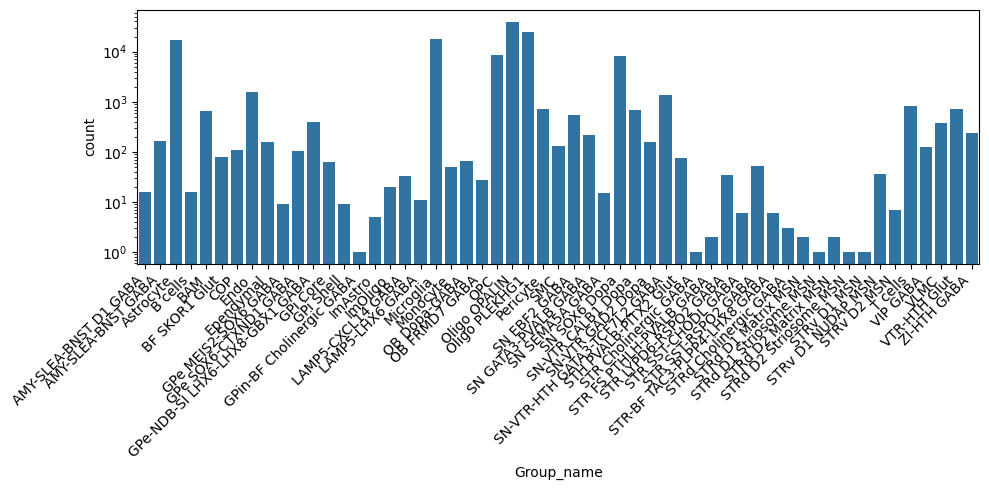

In [16]:
plt.figure(figsize=(10, 5))
sns.countplot(x="Group_name", data=adata.obs)
plt.xticks(rotation=45, ha="right")
plt.yscale("log")  # use log scale for better visibility if counts are very different
plt.tight_layout()
plt.show()

In [ ]:
# # remove to few cell types
# ct_too_few = adata.obs["supercluster_name"].value_counts()[adata.obs["supercluster_name"].value_counts() < 100].index.tolist()
# print(ct_too_few)

# adata.obs["supercluster_name"] = adata.obs["supercluster_name"].replace(ct_too_few, "Miscellaneous")


KeyError: 'supercluster_name'

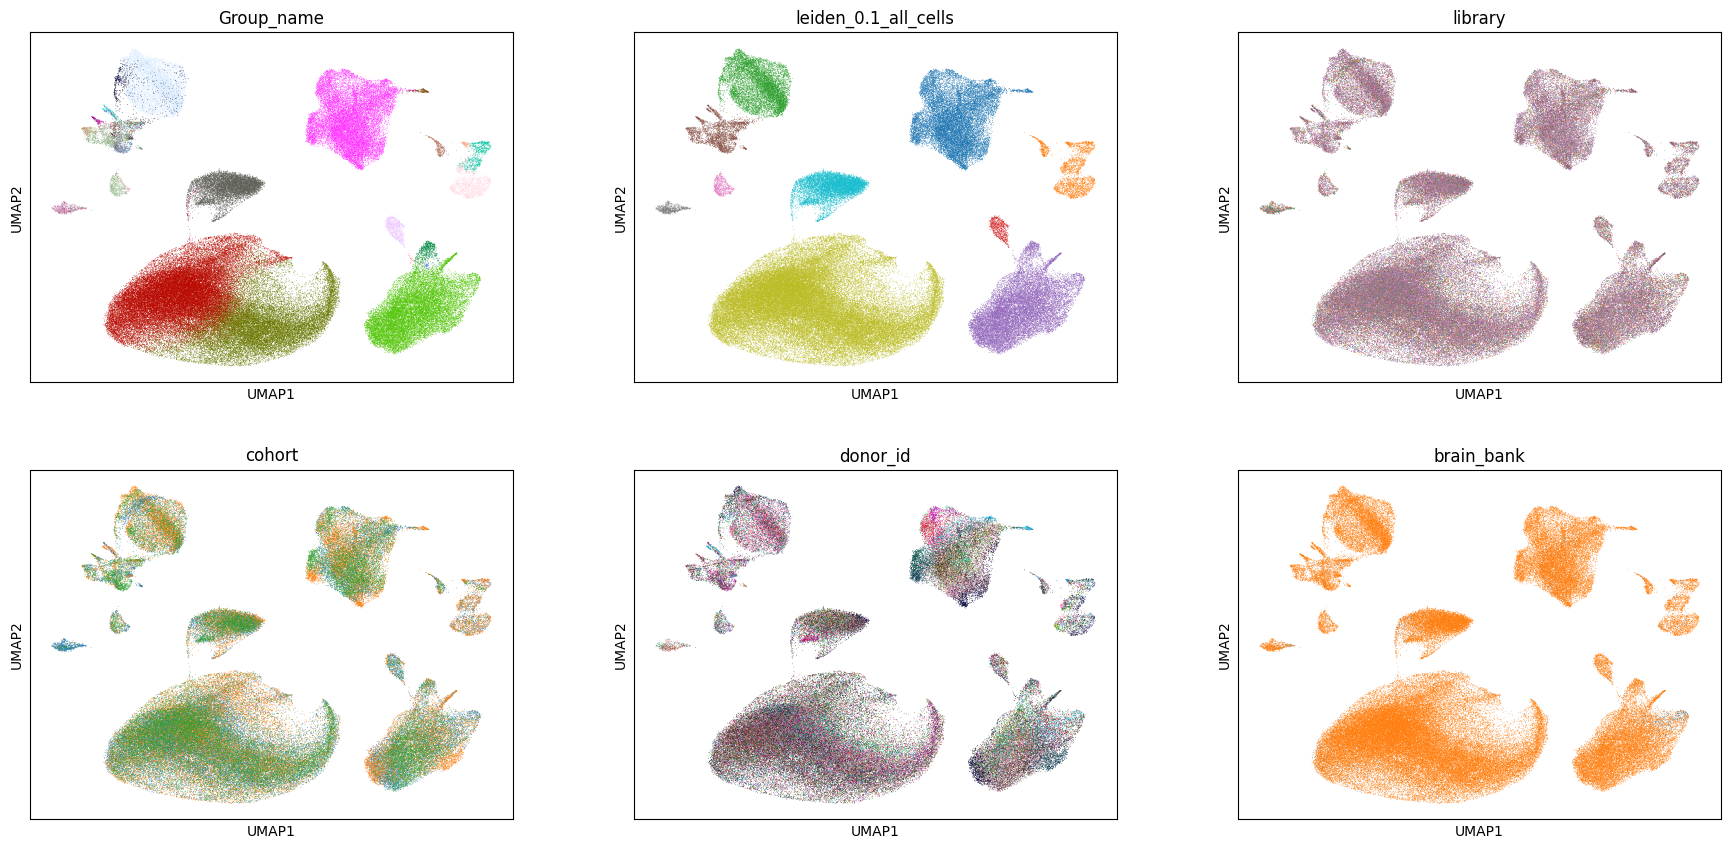

In [6]:
sc.pl.umap(adata, color=["Group_name", leiden_cluster_names[0], "library", "cohort", "donor_id", "brain_bank"], ncols=3, legend_loc=None)

Assure that adata.var.index has same gene name of makers...


  0%|          | 0/6 [00:00<?, ?it/s]

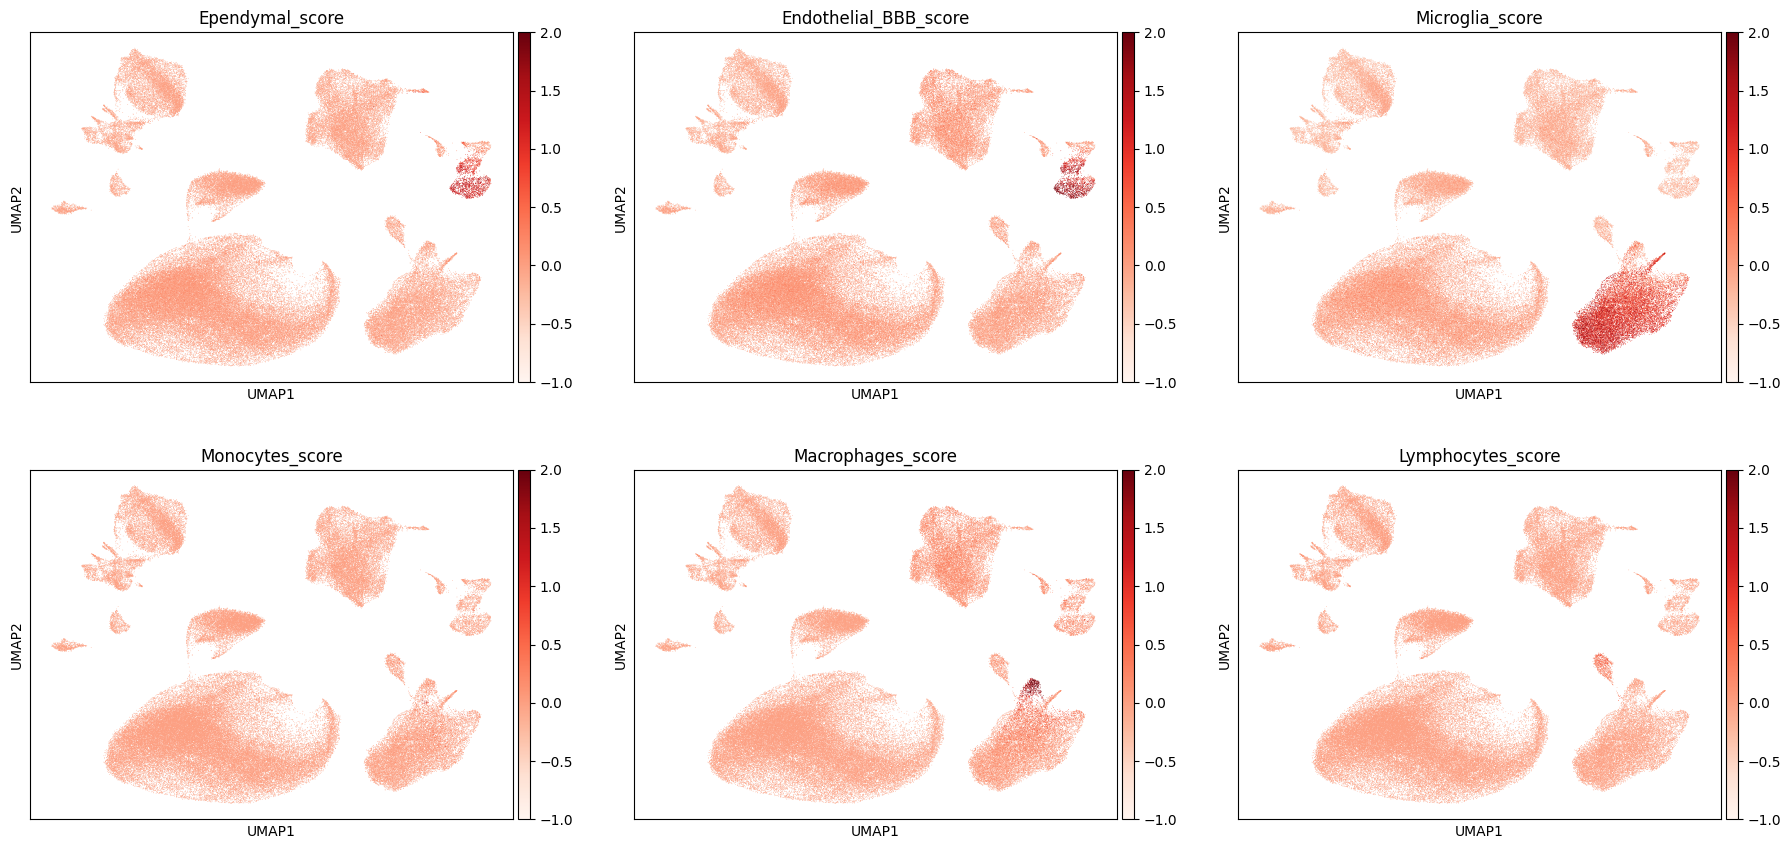

In [7]:
col_scores = preprocessing.calculate_and_plot_markers(adata, markers_ct, gene_col="gene_symbol", ncol=3, layer="log1p_norm", color_map="Reds", umap_name=f"umap", vmin=-1, vmax=2)

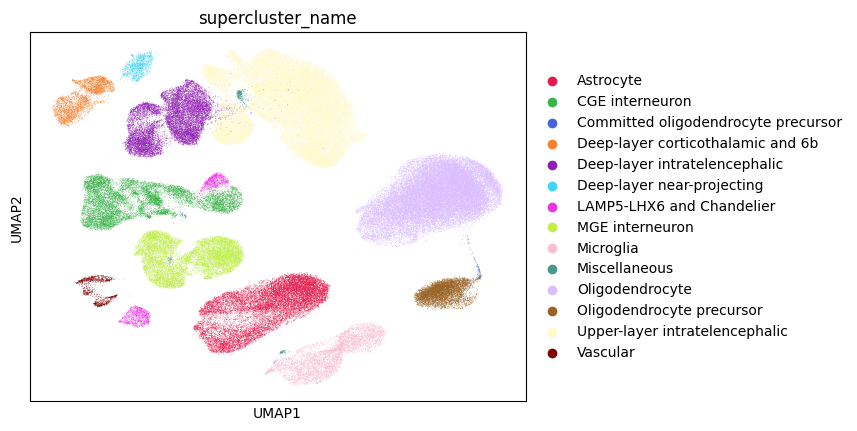

In [8]:
custom_palette = [
    "#e6194b", "#3cb44b", "#4363d8", "#f58231", "#911eb4",
    "#42d4f4", "#f032e6", "#bfef45", "#fabed4", "#469990",
    "#dcbeff", "#9A6324", "#fffac8", "#800000", "#aaffc3",
    "#808000", "#ffd8b1", "#000075", "#a9a9a9", "#ffffff",
    "#000000", "#e6beff"
]

sc.pl.umap(adata, color=["supercluster_name"], palette=custom_palette)

### Final decision

there should be zero ependymal cells in DFC by definition


ct_for_deg
excitatory neuron IT    47972
Oligodendrocyte         37725
interneuron             25030
Astrocyte               15541
OPC                      6432
Microglia                6396
excitatory neuron ET     3727
excitatory neuron        1263
Vascular                 1089
-low_quality              566
Name: count, dtype: int64


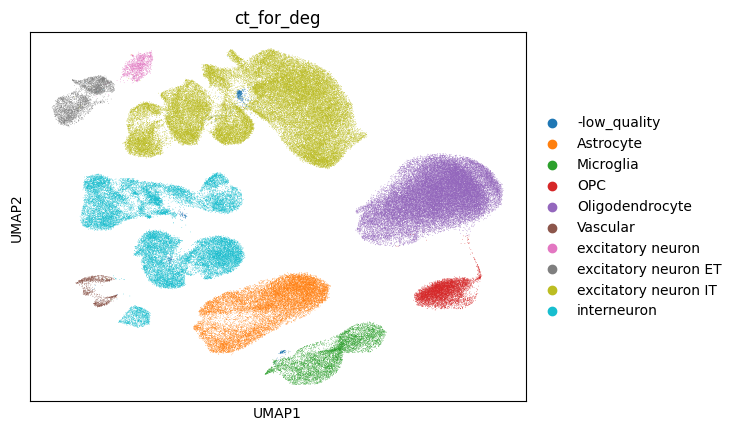

In [9]:

# map clusters to yout ct
mapping_dict = {
    "Astrocyte":                           "Astrocyte",
    "Bergmann glia":                       "Astrocyte",

    "Fibroblast":                          "Fibroblast",

    "Vascular":                            "Vascular", # REFINE LATER
    "Microglia":                           "Microglia", # REFINE LATER
    
    "Eccentric medium spiny neuron":       "eMSN",

    # cortical inh
    "MGE interneuron":                     "interneuron",
    "CGE interneuron":                     "interneuron",
    "LAMP5-LHX6 and Chandelier":           "interneuron",

    # conrtical excitatory
    "Upper-layer intratelencephalic":      "excitatory neuron IT",
    "Deep-layer intratelencephalic":       "excitatory neuron IT",
    "Deep-layer corticothalamic and 6b":   "excitatory neuron ET",
    "Deep-layer near-projecting":          "excitatory neuron",

    "Hippocampal CA1-3":                   "Hippocampal",
    "Cerebellar inhibitory":               "Cerebellum neuron",
    "Upper rhombic lip":                   "Cerebellum neuron",
    "Thalamic excitatory":                 "Thalamic excitatory",

    "Committed oligodendrocyte precursor": "OPC",
    "Oligodendrocyte precursor":           "OPC",
    "Oligodendrocyte":                     "Oligodendrocyte",

    "Splatter":                            "-low_quality",
    "Miscellaneous":                       "-low_quality",
}

adata.obs["ct_for_deg"] = adata.obs["supercluster_name"].map(mapping_dict)

print(adata.obs["ct_for_deg"].value_counts())
sc.pl.umap(adata, color="ct_for_deg")

# Save

In [10]:
adata.X = adata.layers["counts"].copy()

In [11]:
adata.write_h5ad(SAVE_PATH)